### id:20221229
### name:hadeer abdelhady Eessa sayd ahmed 

In [ ]:

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import time

from collections import defaultdict

## 1-set the environment:

In [ ]:

'''
the state is represented as (position,velocity) of car
position ∈ [-1.2, 0.6]
velocity ∈ [-0.07, 0.07]
position and velocity can take any real value in the range of [-1.2, 0.6] and [-0.07, 0.07] respectively.
so we need to discretize them to make each of velocity and position take discrete values only
by dividing each of them into 20 bins and represent each bin with its corresponding index
'''

class MountainCarContinuousAdapter:
    def __init__(self, n_position_bins=50, n_velocity_bins=50):
         self.env = gym.make("MountainCarContinuous-v0")
         self.actions = [-1.0,-0.9,-0.8,-0.7,-0.6,-0.5,-0.4,-0.3,-0.2,-0.1, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
         self.n_actions = len(self.actions)
         self.n_position_bins = n_position_bins
         self.n_velocity_bins = n_velocity_bins
         self.position_min = self.env.observation_space.low[0]
         self.position_max = self.env.observation_space.high[0]

         self.velocity_min = self.env.observation_space.low[1]
         self.velocity_max = self.env.observation_space.high[1]
         self.position_bin_width = (self.position_max - self.position_min) / self.n_position_bins
         self.velocity_bin_width = (self.velocity_max - self.velocity_min) / self.n_velocity_bins
         self.current_state = None
         self.n_states = self.n_position_bins * self.n_velocity_bins

    def discretize(self, state):
        position, velocity = state
        pos_bin = int((position - self.position_min) / self.position_bin_width)# see in which intervel this position exist and truncate fraction because we start bins from zero based
        vel_bin = int((velocity - self.velocity_min) / self.velocity_bin_width)
        pos_bin = np.clip(pos_bin, 0, self.n_position_bins - 1)#make pos bin a value between zero and number of positions-1=19
        vel_bin = np.clip(vel_bin, 0, self.n_velocity_bins - 1)##make velocity bin a value between zero and number of positions-1=19
        return (pos_bin, vel_bin)
    def reset(self):
        state, info = self.env.reset()
        discrete_state = self.discretize(state)
        self.current_state = discrete_state
        return discrete_state

    def step(self, action_index):
          real_action = self.actions[action_index]
          next_state, reward, terminated, truncated, info = self.env.step([real_action])
          discrete_state = self.discretize(next_state)
          self.current_state = discrete_state
          done = terminated or truncated
          return discrete_state, reward, done, info

    def render(self):
        return self.env.render()

    def state_to_key(self, state):
        return state


    def get_config(self):
        return {
            "position_bins": self.n_position_bins,
            "velocity_bins": self.n_velocity_bins,
            "actions": self.actions
        }


## 2-set sarsa algorithm 
## What We Will Do

SARSA is an:

```text
On-Policy Temporal Difference (TD) Control Algorithm
```

Meaning:

> The agent learns using the SAME policy that it follows during training.

The agent:

1. Chooses an action using the current policy (ε-greedy)
2. Executes the action
3. Observes the reward and next state
4. Chooses the next action using the SAME ε-greedy policy
5. Updates the Q-value using the action actually taken

---

## SARSA Update Rule

$$
Q(S_t, A_t)
\leftarrow
Q(S_t, A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma Q(S_{t+1}, A_{t+1})
-
Q(S_t, A_t)
\right]
$$

---

## Meaning of Symbols

| Symbol | Meaning |
|---|---|
| $S_t$ | Current state |
| $A_t$ | Current action |
| $R_{t+1}$ | Reward received after taking the action |
| $S_{t+1}$ | Next state |
| $A_{t+1}$ | Next action selected using the same policy |
| $\alpha$ | Learning rate |
| $\gamma$ | Discount factor |

---

## Important Idea

SARSA is called:

```text
On-Policy
```

because:

> it updates Q-values using the action actually selected by the current ε-greedy policy.

Therefore, SARSA learns the value of the policy it is currently following, including exploratory actions.

In [10]:
class SARSAAgent:

    def __init__(
        self,
        env,
        gamma=0.99,
        alpha=0.5,
        epsilon=0.1
    ):

        self.env = env

        self.gamma = gamma
        self.alpha = alpha
        self.epsilon = epsilon
        self.n_states=env.n_states

        # Q-table
        self.Q = np.ones((
         env.n_position_bins,
         env.n_velocity_bins,
         env.n_actions
        )) * 10

        self.policy = {}

        self.episode_rewards = []
        self.episode_lengths = []

    
    # Epsilon Greedy
   
    def epsilon_greedy(self, state):

        if np.random.random() < self.epsilon:
            return np.random.randint(self.env.n_actions)

        position, velocity = state

        return np.argmax(
            self.Q[position, velocity]
        )

   
    # SARSA Update
   
    def sarsa_update(
        self,
        state,
        action,
        reward,
        next_state,
        next_action
    ):

        p, v = state
        np_, nv = next_state

        current_q = self.Q[p, v, action]

        next_q = self.Q[np_, nv, next_action]

        td_target = reward + self.gamma * next_q

        td_error = td_target - current_q

        self.Q[p, v, action] += self.alpha * td_error

    # Training
   
    def train(self, n_episodes=1000):

        for episode in range(n_episodes):

            state = self.env.reset()

            action = self.epsilon_greedy(state)

            done = False

            total_reward = 0
            steps = 0

            while not done:

                next_state, reward, done, info = self.env.step(action)#discrete_state, reward, done, info

                next_action = self.epsilon_greedy(next_state)

                self.sarsa_update(
                    state,
                    action,
                    reward,
                    next_state,
                    next_action
                )

                state = next_state
                action = next_action

                total_reward += reward
                steps += 1

            self.episode_rewards.append(total_reward)
            self.episode_lengths.append(steps)

    
    # Extract Greedy Policy
    #policy is a dictionary that maps each state to the action with the highest q value in that state
    def get_policy(self):

        for i in range(self.env.n_position_bins):
            for j in range(self.env.n_velocity_bins):

                self.policy[(i, j)] = np.argmax(
                    self.Q[i, j]#without argmax it return the q values for all actions in this state but with argmax it return the index of the action with the highest q value which is the action we will take in this state according to our policy
                )

        return self.policy

## 3- set qlearning algorithm

## What We Will Do

Q-Learning is an:

```text
Off-Policy Temporal Difference (TD) Control Algorithm
```

Meaning:

> The agent learns the optimal greedy policy regardless of the policy currently used for exploration.

The agent:

1. Chooses an action using the current policy (ε-greedy)
2. Executes the action
3. Observes the reward and next state
4. Updates the Q-value using the maximum possible next-state Q-value
5. Continues learning toward the optimal policy

---

## Q-Learning Update Rule

$$
Q(S_t, A_t)
\leftarrow
Q(S_t, A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma \max_a Q(S_{t+1}, a)
-
Q(S_t, A_t)
\right]
$$

---

## Meaning of Symbols

| Symbol | Meaning |
|---|---|
| $S_t$ | Current state |
| $A_t$ | Current action |
| $R_{t+1}$ | Reward received after taking the action |
| $S_{t+1}$ | Next state |
| $\max_a Q(S_{t+1}, a)$ | Maximum Q-value among all possible next actions |
| $\alpha$ | Learning rate |
| $\gamma$ | Discount factor |

---

## Important Idea

Q-Learning is called:

```text
Off-Policy
```

because:

> it updates Q-values using the greedy maximum action value, not necessarily the action actually selected by the current policy.

Therefore, Q-Learning learns directly toward the optimal policy even while exploring randomly using ε-greedy exploration.

In [11]:
class QLearningAgent:

    def __init__(
        self,
        env,
        gamma=0.99,
        alpha=0.5,
        epsilon=0.1
    ):

        self.env = env

        self.gamma = gamma
        self.alpha = alpha
        self.epsilon = epsilon

         # Q-table
        self.Q = np.ones((
         env.n_position_bins,
         env.n_velocity_bins,
         env.n_actions
        )) * 10

        self.policy = {}

        self.episode_rewards = []
        self.episode_lengths = []
        self.n_states=env.n_states

   
    # Epsilon Greedy
    
    def epsilon_greedy(self, state):

        if np.random.random() < self.epsilon:
            return np.random.randint(self.env.n_actions)

        p, v = state

        return np.argmax(self.Q[p, v])

    
    # Q-Learning Update
   
    def q_learning_update(
        self,
        state,
        action,
        reward,
        next_state
    ):

        p, v = state
        np_, nv = next_state

        current_q = self.Q[p, v, action]

        max_next_q = np.max(
            self.Q[np_, nv]
        )

        td_target = reward + self.gamma * max_next_q

        td_error = td_target - current_q

        self.Q[p, v, action] += self.alpha * td_error

    # Training
    
    def train(self, n_episodes=1000):

        for episode in range(n_episodes):

            state = self.env.reset()

            done = False

            total_reward = 0
            steps = 0

            while not done:

                action = self.epsilon_greedy(state)

                next_state, reward, done,info = self.env.step(action)

                self.q_learning_update(
                    state,
                    action,
                    reward,
                    next_state
                )

                state = next_state

                total_reward += reward
                steps += 1

            self.episode_rewards.append(total_reward)#calculate total reward per episode 
            self.episode_lengths.append(steps)#total number of step you take to terminate episode

    
    # Policy Extraction
    
    def get_policy(self):

        for i in range(self.env.n_position_bins):
            for j in range(self.env.n_velocity_bins):

                self.policy[(i, j)] = np.argmax(
                    self.Q[i, j]
                )

        return self.policy

In [12]:
class Visualiser:

    @staticmethod
    @staticmethod
    def plot_episode_rewards(agents, labels):

     fig, axes = plt.subplots(1, len(agents), figsize=(6 * len(agents), 5))

     for ax, agent, label in zip(axes, agents, labels):

        ax.plot(agent.episode_rewards)
        ax.set_xlabel("Episode")
        ax.set_ylabel("Reward")
        ax.set_title(f"Episode Rewards - {label}")

     plt.tight_layout()
     plt.show()

    # -----------------------------------
    @staticmethod
    def plot_episode_lengths(agents, labels):

     fig, axes = plt.subplots(
        1,
        len(agents),
        figsize=(6 * len(agents), 5)
        )

    # If there is only one agent
     if len(agents) == 1:
        axes = [axes]

     for ax, agent, label in zip(axes, agents, labels):

        ax.plot(agent.episode_lengths)

        ax.set_xlabel("Episode")
        ax.set_ylabel("Episode Length")

        ax.set_title(
            f"Episode Lengths - {label}"
        )

     plt.tight_layout()

     plt.show()

    
    @staticmethod
    def plot_q_value_heatmap(agent, title):

        heatmap = np.max(agent.Q, axis=2)

        plt.figure(figsize=(8, 6))

        plt.imshow(
            heatmap,
            cmap="viridis",
            origin="lower",
            aspect="auto"
        )

        plt.colorbar(label="Max Q-value")

        plt.xlabel("Velocity")
        plt.ylabel("Position")

        plt.title(title)

        plt.show()

In [13]:
env = MountainCarContinuousAdapter()

sarsa_agent = SARSAAgent(
    env,
    gamma=0.99,
    alpha=0.5,
    epsilon=0.1
)

q_agent = QLearningAgent(
    env,
    gamma=0.99,
    alpha=0.5,
    epsilon=0.1
)

# Train SARSA
sarsa_agent.train(1000)

# Train Q-Learning
q_agent.train(1000)

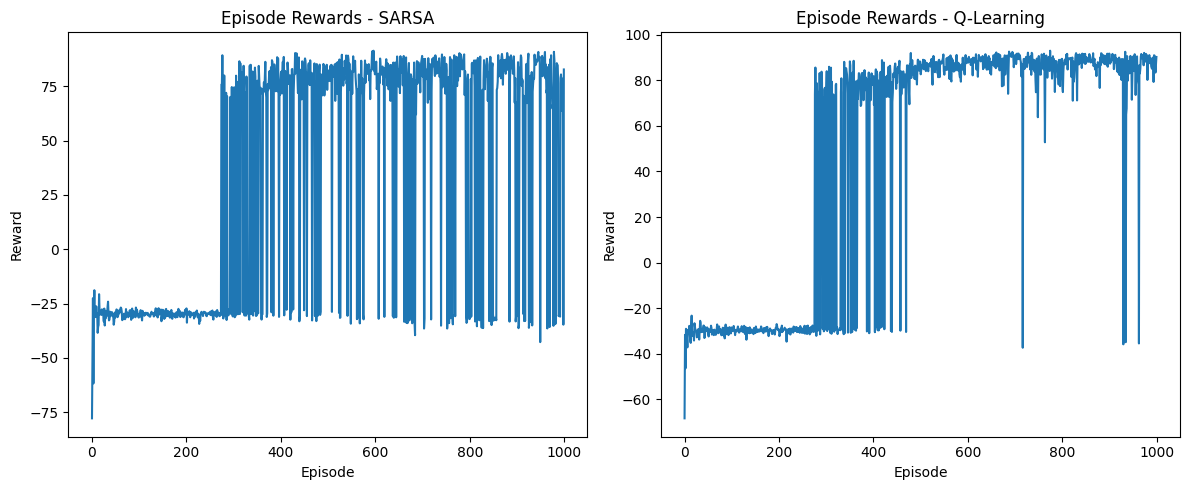

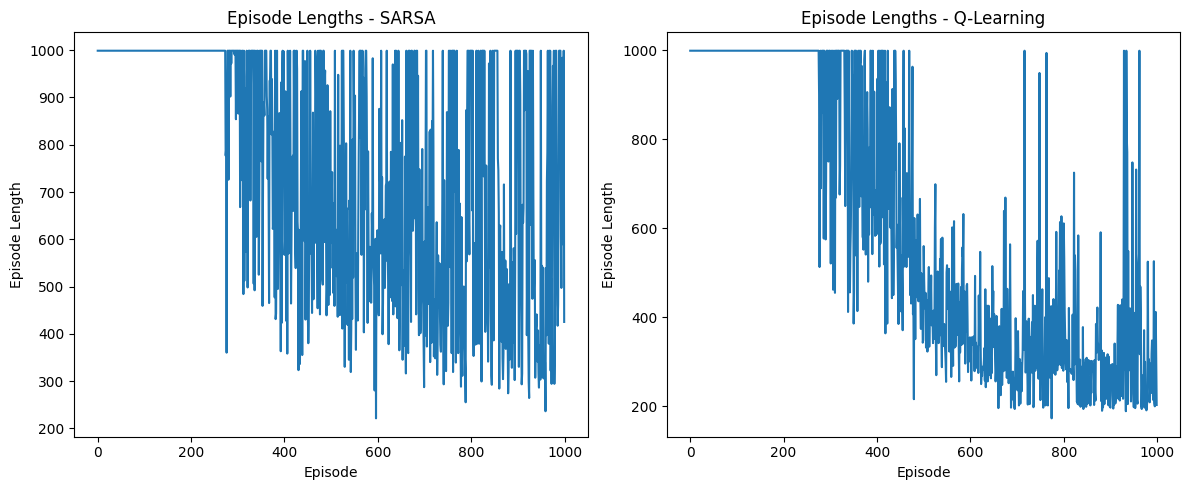

In [14]:
Visualiser.plot_episode_rewards(
    [sarsa_agent, q_agent],
    ["SARSA", "Q-Learning"]
)

Visualiser.plot_episode_lengths(
    [sarsa_agent, q_agent],
    ["SARSA", "Q-Learning"]
)

In [15]:
sarsa_avg = np.mean(
    sarsa_agent.episode_rewards[-100:]
)

q_avg = np.mean(
    q_agent.episode_rewards[-100:]
)

print("SARSA Avg Reward (Last 100 Ep.):", round(sarsa_avg, 2))
print("Q-Learning Avg Reward (Last 100 Ep.):", round(q_avg, 2))

print("SARSA Best Episode Reward:", round(max(sarsa_agent.episode_rewards), 2))
print("Q-Learning Best Episode Reward:", round(max(q_agent.episode_rewards), 2))


SARSA Avg Reward (Last 100 Ep.): 54.58
Q-Learning Avg Reward (Last 100 Ep.): 83.15
SARSA Best Episode Reward: 91.3
Q-Learning Best Episode Reward: 92.97


## 3.1 SARSA vs Q-Learning on MountainCarContinuous-v0

### Training Settings

- γ (gamma) = 0.99
- α (alpha) = 0.5
- ε (epsilon) = 0.1
- Episodes = 1000
- State space: discretized into 50 × 50 bins (position × velocity)
- Action space: 21 discrete values from -1.0 to 1.0

---

### Learning Curves

The plots above show:

**Episode Rewards (top plot):**
- Both agents start with very low (negative) rewards in early episodes
- Around episode 200–250, both agents begin solving the task and rewards jump to around 75–80
- Q-Learning  tends to rise slightly faster and stays more stable at higher rewards
- SARSA  also reaches high rewards but shows more drops and instability in later episodes

**Episode Lengths (bottom plot):**
- Both agents start at the maximum episode length (1000 steps), meaning they fail early on
- After episode ~200, both agents start finishing faster (lower steps = better)
- Q-Learning generally reaches shorter episode lengths sooner
- SARSA takes slightly longer to stabilize and still shows some long episodes late in training

---

### Average Reward (Last 100 Episodes)

| Agent | Avg Reward (Last 100 Ep.) | Best Episode Reward | Converged? | Notes |
|------------|--------------------------|---------------------|------------|-------|
| SARSA | 54.58 | 91.3 | Partially | Converges but still has occasional failure episodes (reward drops). More conservative due to on-policy updates. |
| Q-Learning | 83.15 | 92.97| Yes | More stable convergence. Off-policy updates allow it to learn the optimal policy more than sarsa. |

---

### Qualitative Differences

- **Q-Learning** is an **off-policy** method. It always updates toward the best possible next action (greedy), even if it did not actually take that action. This makes it learn the optimal policy faster and reach higher average rewards.

- **SARSA** is an **on-policy** method. It updates based on the action it actually took (including exploratory actions). This makes it more cautious and sometimes slower to converge, especially when ε-greedy exploration still picks random actions.

- In this task, Q-Learning clearly outperforms SARSA in terms of final average reward ( 83.15 vs 54.58  ), which is expected because the MountainCar task benefits from greedy value estimation.


Alpha=0.1 Avg Reward (Last 100 Ep.): 0.91
Alpha=0.1 Best Episode Reward: 84.91
------------------------------
Alpha=0.5 Avg Reward (Last 100 Ep.): 83.49
Alpha=0.5 Best Episode Reward: 93.72
------------------------------
Alpha=0.9 Avg Reward (Last 100 Ep.): 24.41
Alpha=0.9 Best Episode Reward: 91.59
------------------------------


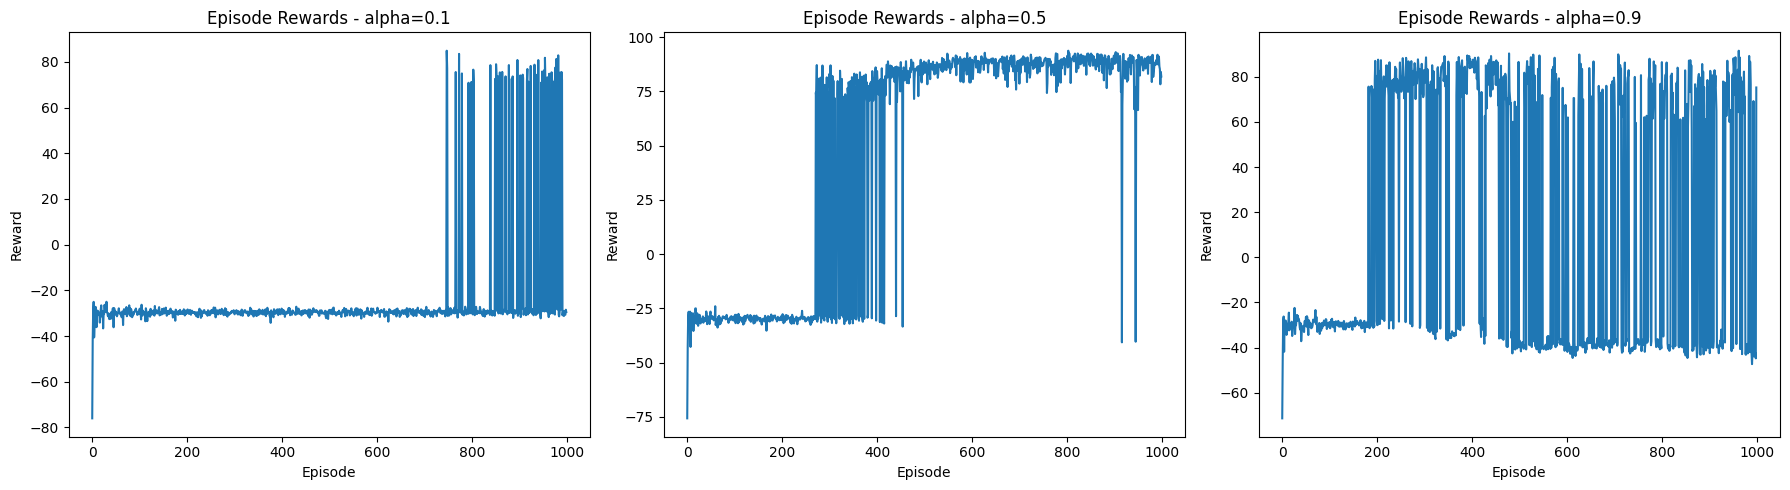

In [16]:
alphas = [0.1, 0.5, 0.9]

agents = []

for alpha in alphas:

    env = MountainCarContinuousAdapter()

    agent = QLearningAgent(
        env,
        alpha=alpha,
        gamma=0.99,
        epsilon=0.1
    )

    agent.train(1000)

    agents.append(agent)
    
for alpha, agent in zip(alphas, agents):
    avg_reward = np.mean(agent.episode_rewards[-100:])
    print(f"Alpha={alpha} Avg Reward (Last 100 Ep.): {avg_reward:.2f}")
    print(f"Alpha={alpha} Best Episode Reward: {max(agent.episode_rewards):.2f}")
    print("-" * 30)

Visualiser.plot_episode_rewards(
    agents,
    [f"alpha={a}" for a in alphas]
)


## 3.2 Effect of Learning Rate (α) on Q-Learning

### Comparison Table

| α | Avg Reward (Last 100 Ep.) | Best Episode Reward | Convergence Speed | Stability | Notes |
|-----|--------------------------|---------------------|-------------------|-----------|-------|
| 0.1 | 0.91 | 84.91| Slow (starts improving around episode 800) | Low | Learns too slowly. Still not fully converged after 1000 episodes. Small alpha means tiny updates each step so it takes very long to learn. |
| 0.5 | 83.49 | 93.72 | Medium (starts improving around episode 200–300) | High | Best overall performance. Good balance between learning speed and stability. so it is Recommended choice. |
| 0.9 | 24.41 | 91.59 | Fast (starts improving around episode 200-250) | Low | Large alpha means it updates too strongly and keeps changing the learned values too much, causing it to lose good solutions it already found. |

### Key Takeaway

- **α = 0.1** is too small → agent learns very slowly and does not converge well in 1000 episodes
- **α = 0.5** is in middle → fast enough to learn and stable enough to keep good performance
- **α = 0.9** is too large → agent finds good actions early but then becomes unstable and forgets what it learned

Epsilon=0.01 Avg Reward (Last 100 Ep.): 91.39
Epsilon=0.01 Best Episode Reward: 94.56
------------------------------
Epsilon=0.1 Avg Reward (Last 100 Ep.): 89.47
Epsilon=0.1 Best Episode Reward: 93.80
------------------------------
Epsilon=0.3 Avg Reward (Last 100 Ep.): -19.49
Epsilon=0.3 Best Episode Reward: 91.58
------------------------------


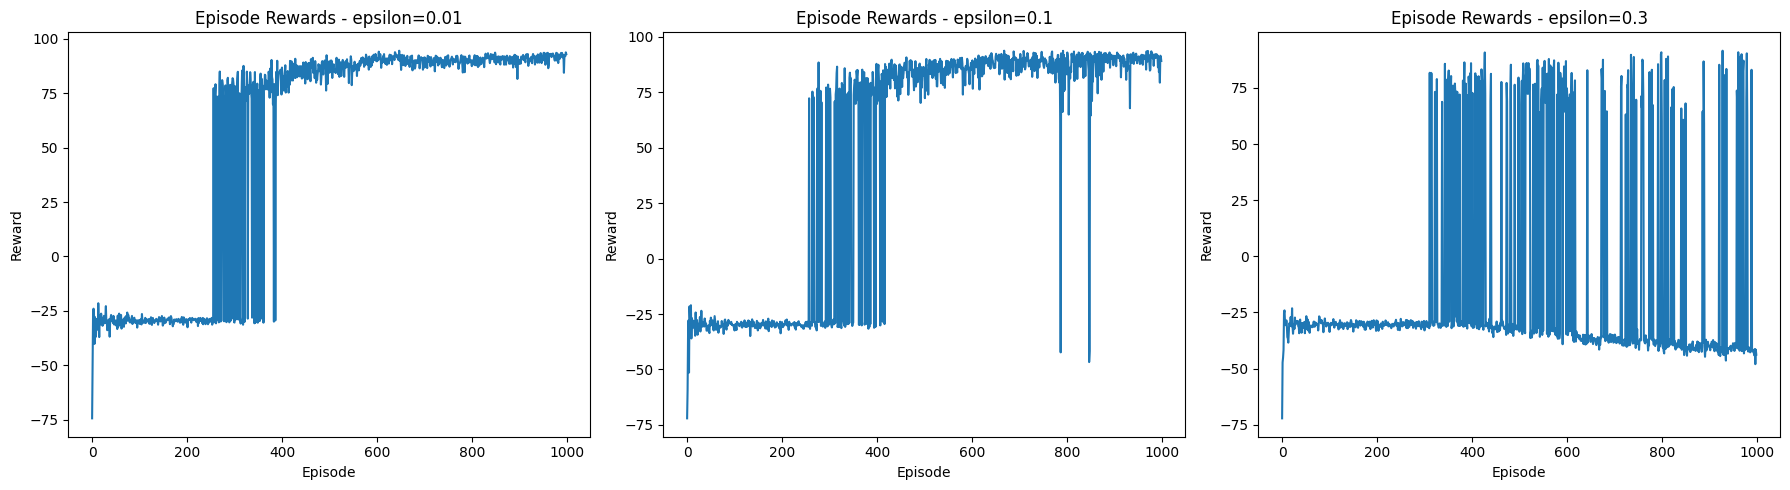

In [17]:
epsilons = [0.01, 0.1, 0.3]

agents = []

for epsilon in epsilons:

    env = MountainCarContinuousAdapter()

    agent = QLearningAgent(
        env,
        alpha=0.5,
        gamma=0.99,
        epsilon=epsilon
    )

    agent.train(1000)

    agents.append(agent)

for epsilon, agent in zip(epsilons, agents):
    avg_reward = np.mean(agent.episode_rewards[-100:])
    print(f"Epsilon={epsilon} Avg Reward (Last 100 Ep.): {avg_reward:.2f}")
    print(f"Epsilon={epsilon} Best Episode Reward: {max(agent.episode_rewards):.2f}")
    print("-" * 30)

Visualiser.plot_episode_rewards(
    agents,
    [f"epsilon={e}" for e in epsilons]
)

## 3.3 Effect of Exploration Rate (ε) on Q-Learning

### Comparison Table

| ε | Avg Reward (Last 100 Ep.) | Best Episode Reward | Exploration vs Exploitation Balance | Policy Quality | Notes |
|------|--------------------------|---------------------|--------------------------------------|----------------|-------|
| 0.01 | 91.39 | 94.56 | Almost pure exploitation (1% random) | Best | Agent mostly uses what it learned. Converges fast and stays very stable after episode ~300. Very little random actions means it sticks to the best policy it found. |
| 0.10 | 89.47 | 93.80 | Balanced (10% random) | Good | Good balance between trying new actions and using learned ones. Slightly less stable than 0.01 but still converges well. This is the standard recommended value. |
| 0.30 | -19.49 | 91.58 | Too much exploration (30% random) | Poor | Agent keeps taking random actions too often even after learning good ones. This stops it from settling on a good policy. Best episode reward shows it can solve the task but average is very low because of constant random exploration. |

### Key Takeaway

- **ε = 0.01** gives the best average reward because the agent mostly follows its learned policy with very little random noise
- **ε = 0.10** is a good safe choice that balances exploration and exploitation well
- **ε = 0.30** is too high for this task. Too many random actions prevent the agent from using what it already learned, so performance stays poor on average

note that q_learining : when you updata ,you updata based on greedy policy and when you execute or select action , you select based on e_greedy policy

20x20 Total States: 400
20x20 Training Time: 9.94 seconds
20x20 Avg Reward (Last 100 Ep.): 84.93
20x20 Best Episode Reward: 95.14
------------------------------
40x40 Total States: 1600
40x40 Training Time: 15.22 seconds
40x40 Avg Reward (Last 100 Ep.): 75.80
40x40 Best Episode Reward: 93.27


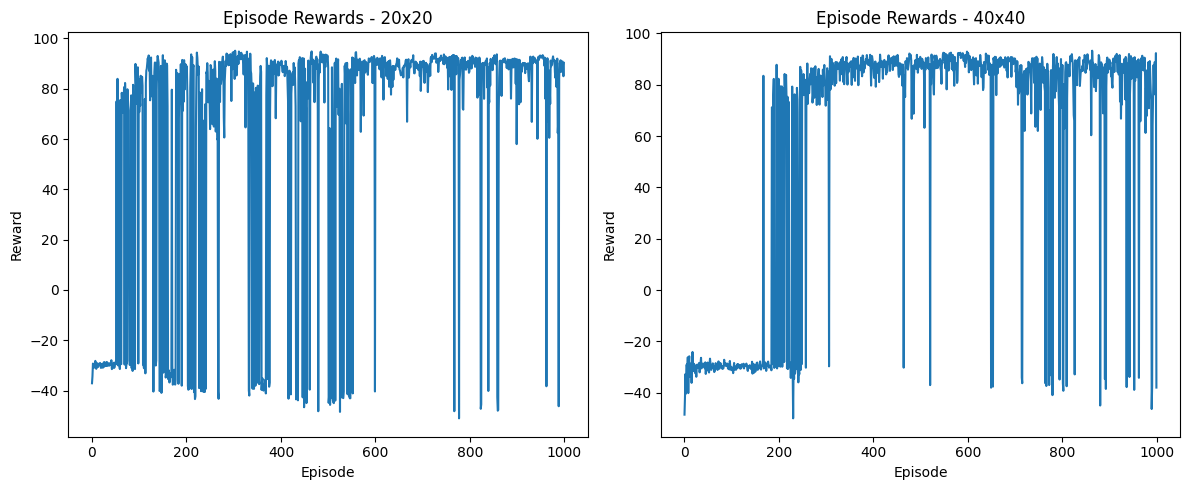

In [18]:
import time
coarse_env = MountainCarContinuousAdapter(
    n_position_bins=20,
    n_velocity_bins=20
)

fine_env = MountainCarContinuousAdapter(
    n_position_bins=40,
    n_velocity_bins=40
)

coarse_agent = QLearningAgent(coarse_env)
fine_agent = QLearningAgent(fine_env)

start = time.time()
coarse_agent.train(1000)
coarse_time = time.time() - start

start = time.time()
fine_agent.train(1000)
fine_time = time.time() - start

# Print results
print(f"20x20 Total States: {coarse_agent.n_states}")
print(f"20x20 Training Time: {coarse_time:.2f} seconds")
print(f"20x20 Avg Reward (Last 100 Ep.): {np.mean(coarse_agent.episode_rewards[-100:]):.2f}")
print(f"20x20 Best Episode Reward: {max(coarse_agent.episode_rewards):.2f}")
print("-" * 30)
print(f"40x40 Total States: {fine_agent.n_states}")
print(f"40x40 Training Time: {fine_time:.2f} seconds")
print(f"40x40 Avg Reward (Last 100 Ep.): {np.mean(fine_agent.episode_rewards[-100:]):.2f}")
print(f"40x40 Best Episode Reward: {max(fine_agent.episode_rewards):.2f}")


Visualiser.plot_episode_rewards(
    [coarse_agent, fine_agent],
    ["20x20", "40x40"]
)

## 3.4 Effect of State Space Discretization on Q-Learning

### Comparison Table

| Bins (pos × vel) | Total States | Avg Reward (Last 100 Ep.) | Best Episode Reward | Training Time | Notes |
|------------------|--------------|--------------------------|---------------------|---------------|-------|
| 20 × 20 | 400 | 84.93 | 95.14 | 9.94 seconds  | Fewer states means the agent learns faster and converges earlier (around episode 50). However, the state space is too rough so the agent cannot tell similar positions apart very well, leading to occasional bad episodes. |
| 40 × 40 | 1600 | 75.80 | 93.27 | 15.22 seconds | More states means a finer map of the environment but the agent needs more episodes to visit and learn all states. Converges later (around episode 200) and is less stable in the last 100 episodes. Training takes about 2x longer. |

### Key Takeaway

- **20×20** gives better average reward in 1000 episodes because the smaller state space is easier and faster to learn
- **40×40** can reach similar best episode rewards but needs more than 1000 episodes to fully converge since there are 4x more states to explore
- There is a trade-off: finer discretization gives more detail about the environment but requires much more training time and episodes to converge

## Final Comparison: DP vs MC vs TD Methods

### Comparison Table

| Method | Best Avg Return | Episodes/Iterations | Main Advantage | Main Limitation |
|--------------|----------------|---------------------|----------------|-----------------|
| DP - Value Iteration (Assignment 1) | Max value: 100.0, Mean value: 4.52 | 82 iterations | Very fast convergence. Finds the optimal solution in very few iterations  | Requires full knowledge of transition probabilities (env.P). Cannot work on environments like MountainCar where physics are unknown |
| DP - Policy Iteration (Assignment 1) | Max value: 100.0, Mean value: 4.52 | 18 iterations | Fastest convergence of all methods. Reaches same solution as Value Iteration in far fewer iterations | Same as Value Iteration — needs a full transition table. Not usable in real or continuous environments |
| MC Control (Assignment 2) | -19.56 (last 100 ep.) | 1000 episodes | Does not need transition probabilities. Learns directly from complete episodes of experience | Needs to wait until the end of each episode to update. Very slow to converge and performs poorly on hard tasks like MountainCar |
| SARSA (Task 3) | 54.58 (last 100 ep.), Best: 91.3 | 1000 episodes | Safe on-policy learning. Updates at every step not end of episode so faster than MC | Slower than Q-Learning because it updates based on the action it actually took including random exploratory ones |
| Q-Learning (Task 3) | 83 (last 100 ep.), Best:92.97| 1000 episodes | Best performance among model-free methods. Off-policy updates always aim for the best possible action leading to faster and stronger convergence | Can be unstable with wrong hyperparameters (high alpha or epsilon). Still needs discretization for continuous environments |

### Key Takeaway

- **DP methods** (VI and PI) are the most efficient in iterations but only work when the full environment model is known
- **MC Control** is the weakest here because MountainCar is a hard task and MC needs many more episodes to converge
- **Q-Learning** is the best practical choice for this task with no environment model needed and strong final performance

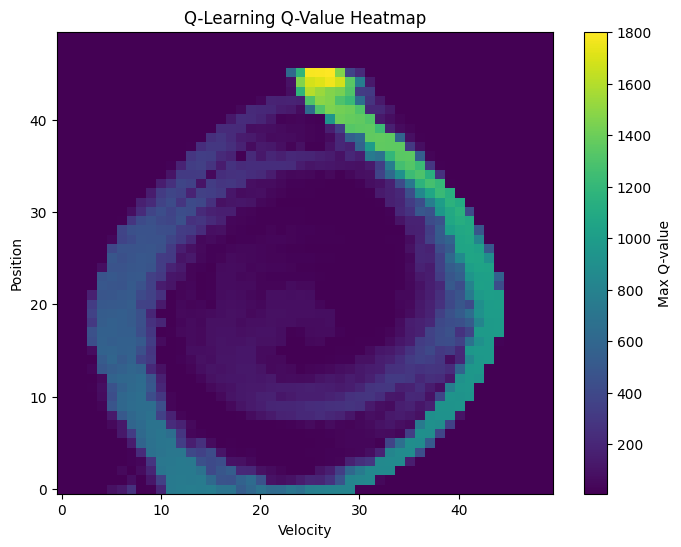

In [19]:
Visualiser.plot_q_value_heatmap(
    q_agent,
    "Q-Learning Q-Value Heatmap"
)

## Section 5 — Conceptual Questions

---

**1. What is the fundamental difference between TD learning and Monte Carlo methods in terms of when and how updates are performed?**

MC waits until the episode fully ends, then updates using the real total reward collected.
TD updates after every single step using the immediate reward plus its estimate of the next state. TD learns faster because it does not wait for the episode to finish.

---

**2. Explain the concept of bootstrapping and why TD methods bootstrap while Monte Carlo methods do not.**

Bootstrapping means using your own current guesses to update other guesses.
TD does this — it updates the current state value using the estimated value of the next state.
MC does not — it always waits for the real final return and never uses estimates to update.

---

**3. What is the bias-variance trade-off between TD(0) and Monte Carlo prediction? Which method is unbiased? Which typically has lower variance?**

MC is unbiased because it uses real returns, but has high variance because returns change a lot across episodes.
TD is biased because it uses estimates that are not yet accurate, but has low variance because it only looks one step ahead.
In short: MC is honest but noisy. TD is stable but makes assumptions.

---

**4. Why does SARSA learn differently from Q-Learning? Relate your answer to the on-policy vs off-policy distinction.**

SARSA is on-policy — it updates using the action it actually took, including random exploratory ones. It learns the policy it is currently following.
Q-Learning is off-policy — it always updates using the best possible next action, even if it did not take it. It learns the optimal policy directly.
This is why Q-Learning reached 83.15 avg reward while SARSA reached 54.58 in our experiments.

---

**5. How does the learning rate α affect convergence in TD methods? What are the theoretical conditions on α for guaranteed convergence (Robbins-Monro conditions)?**

Small α (0.1) → learns too slowly, may not converge in time.
Large α (0.9) → learns fast at first but becomes unstable and forgets good values.
Best α (0.5) → good balance of speed and stability.

For guaranteed convergence the Robbins-Monro conditions require:
- Sum of all α values over time = infinity (keep learning)
- Sum of all α² values over time is finite (updates shrink over time)

In practice this means α should slowly decrease over training.

---

**6. Compare the three paradigms covered across all tasks — Dynamic Programming (Assignment 1), Monte Carlo (Assignment 2), and Temporal-Difference (Task 3) — in terms of: model requirements, bootstrapping, online vs offline learning, sample efficiency, and computational requirements per step.**

| | DP | MC | TD |
|---|---|---|---|
| Needs environment model | Yes | No | No |
| Bootstrapping | Yes | No | Yes |
| Online learning | No | No | Yes |
| Sample efficiency | High | Low | Medium |
| Cost per step | High (loops all states) | Low | Low |

---

### high sample efficient -> if it learns good behavior using FEW interactions and low sample efficient -> if it needs MANY interactions before learning

**7. Can TD methods be applied to continuing (non-episodic) tasks? Compare this to the limitation of Monte Carlo methods discussed in Assignment 2.**

Yes, TD works on tasks that never end because it updates every step with no need for a terminal state.
MC cannot work on continuing tasks at all because it needs the episode to end to calculate the total return. No terminal state means no return and MC completely breaks down.

---

**8. Based on your experiments on MountainCarContinuous across all three tasks, which paradigm (DP, MC, TD) worked best and why? What does this tell you about the strengths and weaknesses of each approach?**

Q-Learning (TD) worked best with 83.15 avg reward.
DP could not even run because MountainCar has no transition table.
MC only reached -19.56 because episodes are long and returns are very noisy.
TD is the best practical choice for complex environments — it is model-free, learns online, and converges well with the right hyperparameters.

---

**9. What is the deadly triad in reinforcement learning, and which of the methods in this task are susceptible to it?**

The deadly triad is a well-known problem in reinforcement learning that occurs when the following three components are combined together:

1. Function approximation  
   (using a neural network or approximation method instead of a simple Q-table)

2. Bootstrapping  
   (updating estimates using other estimated values rather than waiting for the true final return)

3. Off-policy learning  
   (learning about one policy while following another policy)

When these three components are used together, the learning process can become unstable. The Q-values may continuously increase or oscillate, causing the algorithm to diverge instead of converging to correct values.

Together they can cause value estimates to grow out of control and the agent never converges.

Q-Learning is most at risk because it uses bootstrapping and is off-policy. If we added a neural network it would face all three and could diverge.
SARSA is safer because it is on-policy, removing one part of the triad.
MC is safe because it does not bootstrap.
DP is safe because it is not off-policy and uses no function approximation.